<a href="https://colab.research.google.com/github/madhurrathod/nutrition-and-obesity-trends/blob/main/DataMiningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)

# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets

# metadata
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata)

# variable information
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables)


{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
df = pd.concat([X, y], axis=1)
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

In [ ]:
column_mapping = {
    'FAVC': 'HighCaloricFoodFreq',
    'FCVC': 'VegConsumptionFreq',
    'NCP':  'MealsPerDay',
    'CAEC': 'SnackFoodFreq',
    'CH2O': 'WaterIntakeDaily',
    'SCC':  'CalorieMonitoring',
    'FAF':  'PhysicalActivityFreq',
    'TUE':  'TechDeviceTime',
    'CALC': 'AlcoholConsumption',
    'MTRANS': 'Transportation',
    'NObeyesdad': 'ObesityLevel',
    'family_history_with_overweight': 'FamilyHistory'
}

df = df.rename(columns=column_mapping)

df.head()

,Gender,Age,Height,Weight,FamilyHistory,HighCaloricFoodFreq,VegConsumptionFreq,MealsPerDay,SnackFoodFreq,SMOKE,WaterIntakeDaily,CalorieMonitoring,PhysicalActivityFreq,TechDeviceTime,AlcoholConsumption,Transportation,ObesityLevel
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
label_encoder = LabelEncoder()
df['ObesityLevel'] = label_encoder.fit_transform(df['ObesityLevel'])


categorical_cols = ['Gender', 'FamilyHistory', 'HighCaloricFoodFreq',
                    'SnackFoodFreq', 'SMOKE', 'CalorieMonitoring',
                    'AlcoholConsumption', 'Transportation']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,Age,Height,Weight,VegConsumptionFreq,MealsPerDay,WaterIntakeDaily,PhysicalActivityFreq,TechDeviceTime,ObesityLevel,Gender_Male,...,SnackFoodFreq_no,SMOKE_yes,CalorieMonitoring_yes,AlcoholConsumption_Frequently,AlcoholConsumption_Sometimes,AlcoholConsumption_no,Transportation_Bike,Transportation_Motorbike,Transportation_Public_Transportation,Transportation_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,1,False,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,1,False,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,5,True,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,6,True,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
features_to_scale = ['Age', 'Height', 'Weight', 'VegConsumptionFreq',
                     'MealsPerDay', 'WaterIntakeDaily', 'PhysicalActivityFreq',
                     'TechDeviceTime']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df.head()

,Age,Height,Weight,VegConsumptionFreq,MealsPerDay,WaterIntakeDaily,PhysicalActivityFreq,TechDeviceTime,ObesityLevel,Gender_Male,...,SnackFoodFreq_no,SMOKE_yes,CalorieMonitoring_yes,AlcoholConsumption_Frequently,AlcoholConsumption_Sometimes,AlcoholConsumption_no,Transportation_Bike,Transportation_Motorbike,Transportation_Public_Transportation,Transportation_Walking
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,1,False,...,False,False,False,False,False,True,False,False,True,False
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,1,False,...,False,True,True,False,True,False,False,False,True,False
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1,True,...,False,False,False,True,False,False,False,False,True,False
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,5,True,...,False,False,False,True,False,False,False,False,False,True
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,6,True,...,False,False,False,False,True,False,False,False,True,False


How well can we predict obesity level based only on non-physical factors?


In [ ]:
X_final = df.drop(['ObesityLevel','Weight', 'Height'], axis=1)
y_final = df['ObesityLevel']

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)


In [ ]:
tree_model = DecisionTreeClassifier(criterion='gini', random_state=42,max_depth=3)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

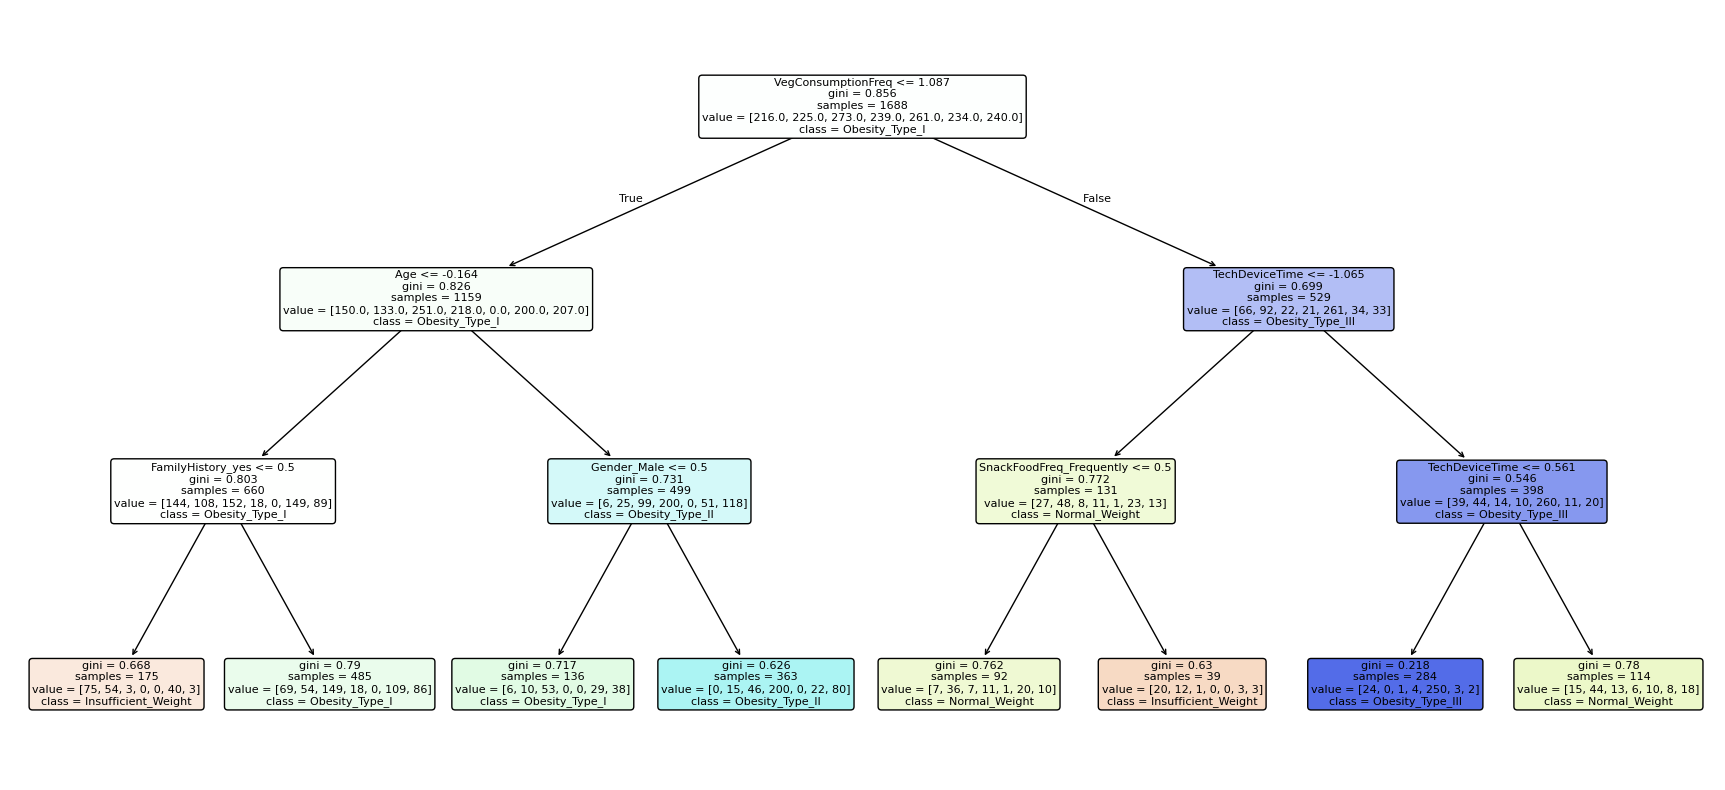

In [ ]:
plt.figure(figsize=(22,10))


plot_tree(tree_model,
          feature_names=X_final.columns,
          class_names=label_encoder.classes_,
          filled=True,
          rounded=True,
          fontsize=8)


plt.show()

*   Vegetable intake is the most crucial initial predictor for sorting different weight categories.
*   A single dietary variable was a better primary differentiator than gender, age, or physical activity levels.


*  High veggie intake's benefits are cancelled out by high screen time, highlighting sedentary behavior as the key problem for otherwise healthy eaters.
*   For those with poor vegetable intake, subsequent risk is primarily driven by Age and Family History, not activity.






